#MTH 5000 – Applied Forecasting of Financial Data
##Final Forecasting Analysis
##By: Liam Duke

### Overview: This notebook presents the results of an independent research study conducted at Baruch College. The objective of this project is to compare the performance of different forecasting approaches—statistical, machine learning, and deep learning—on real-world financial time series data. This analysis focuses specifically on **ConocoPhillips**, highlighting how each methodology performs in predicting its stock price.


### Sections

#### 0. Libraries and Helper Functions

#### 1. Exploratory Data Analysis

* Pulling Data
* Calculating Statistics
* Visualizations
* Splitting and Exporting Data

---

#### 2. ARIMA and SARIMA Models

* Checking for Stationary and Autocorrelation
* Fitting ARIMA and SARIMA Models
* Checking ARIMA and SARIMA Assumptions
* ARIMA and SARIMA Forecast Visualized

---

#### 3. XGBoost Model  
* Feature Engineering for Machine Learning
* Fitting XGBoost Model
* XGBoost Forecast Results and Visualized
* XGBoost Visualized
---

#### 4. LSTM Model  
* Feature Engineering and Scaling for Neural Networks
* Fitting XGBoost Model
* XGBoost Forecast Results and Visualized
* XGBoost Visualized
---

#### 5. Comparing Results  

* Table comparing all model metrics
* Visual plot of all forecasts

---

# **Section 0**: Libraries and Helper Functions

In [58]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving fetch_data.py to fetch_data.py
Saving financial_visuals.py to financial_visuals.py
Saving residual_diagnostics.py to residual_diagnostics.py
User uploaded file "fetch_data.py" with length 1110 bytes
User uploaded file "financial_visuals.py" with length 6402 bytes
User uploaded file "residual_diagnostics.py" with length 2239 bytes


In [59]:
import fetch_data  # Module for retrieving and preprocessing financial time series data
from fetch_data import get_weekly_data  # Function to fetch weekly aggregated stock data

import financial_visuals  # Module for financial plotting utilities (EDA + forecasting visuals)
from financial_visuals import plot_financial_analysis, plot_forecast  # EDA plots and forecast comparison charts

import residual_diagnostics  # Module for model residual analysis and diagnostic testing
from residual_diagnostics import plot_residual_diagnostics  # Visual diagnostics (residuals, ACF, normality checks)

In [60]:
!pip install pmdarima

In [61]:
# Data handling
import pandas as pd  # Data manipulation and time series handling
import numpy as np   # Numerical computations and arrays

# Visualization
import matplotlib.pyplot as plt  # Base plotting library
import seaborn as sns            # Statistical visualizations (distributions, heatmaps)

# Statistics / probability
from scipy.stats import norm, kurtosis  # Normal distribution and distribution shape metrics

# Time series analysis
from statsmodels.tsa.stattools import adfuller  # Stationarity test (ADF test)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # ACF/PACF plots for ARIMA tuning
import statsmodels.api as sm  # ARIMA / SARIMAX and statistical modeling tools

# Auto model selection
import pmdarima as pm  # Auto ARIMA for selecting optimal (p,d,q)

# Utilities
import itertools  # Grid search / parameter combinations

# Model evaluation and tuning
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Forecast accuracy metrics
from sklearn.model_selection import RandomizedSearchCV  # Randomized search with cross-validation
from sklearn.preprocessing import MinMaxScaler #Scaling data for NN

# XGBoost model
from xgboost import XGBRegressor  # Gradient boosting regression using decision trees
from xgboost import plot_importance  # Feature importance visualization

#LSTM Model
from tensorflow.keras.models import Sequential # Linear stack of neural network layers
from tensorflow.keras.layers import LSTM, Dense, Dropout ## LSTM for sequence learning, Dense for output mapping, Dropout for regularization

# **Section 1**: Exploratory Data Analysis

## **Part 1.1**: Pulling Data

In [62]:
fetch_data_df = get_weekly_data("COP", start="2015-01-01", end = "2025-12-30",keep_columns=["Close"])

print(fetch_data_df.head())

Price           Close       High        Low       Open    Volume
Ticker            COP        COP        COP        COP       COP
Date                                                            
2015-01-01  44.044651  48.306592  43.697022  47.625235  47045900
2015-01-08  43.537125  45.532518  42.306516  45.087552  46895800
2015-01-15  44.872009  45.038870  42.674991  44.225418  34895600
2015-01-22  43.509300  45.991374  43.453678  45.261350  35632700
2015-01-29  45.796711  47.249800  42.160504  43.926463  59835200


In [63]:
df = fetch_data_df
df

Price,Close,High,Low,Open,Volume
Ticker,COP,COP,COP,COP,COP
Date,,,,,
2015-01-01,44.044651,48.306592,43.697022,47.625235,47045900
2015-01-08,43.537125,45.532518,42.306516,45.087552,46895800
2015-01-15,44.872009,45.038870,42.674991,44.225418,34895600
2015-01-22,43.509300,45.991374,43.453678,45.261350,35632700
2015-01-29,45.796711,47.249800,42.160504,43.926463,59835200
...,...,...,...,...,...
2025-11-27,91.101036,91.130803,86.209105,86.417483,22612700
2025-12-04,96.052513,96.657803,90.932355,90.932355,41978200


## **Part 1.2**: Calculating Statistics

In [64]:
df["Return"] = df["Close"].pct_change() #Return measures percent change in closing prices
df["Abs_Return"] = df["Return"].abs()  #Absolute Return measures Magnitude of movement without direction
df["High_Low"] = df["High"] - df["Low"] #High-Low difference measures intraday volatility
df["Open_Close_Diff"] = df["Open"] - df["Close"] #Open-Close difference measures weekly price move

In [65]:
#Preprocess and round for precision
df = df.round(3)

df.columns = df.columns.droplevel('Ticker')

In [66]:
#Descriptive Statistics
df.describe()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff
count,574.000000,574.000000,574.000000,574.000000,5.740000e+02,573.000000,573.000000,574.000000,574.000000
mean,62.094239,64.102869,60.053937,62.046890,3.703623e+07,0.002719,0.036119,4.048897,-0.047334
std,28.734414,29.521932,28.064417,28.766575,1.449311e+07,0.052708,0.038454,2.604938,2.916038
min,18.191000,25.107000,16.723000,18.560000,1.438560e+07,-0.341000,0.000000,0.742000,-12.775000
25%,37.595750,38.597000,36.272250,37.598250,2.779225e+07,-0.023000,0.011000,2.145000,-1.481750
50%,49.731500,51.113500,48.194000,49.331500,3.445680e+07,0.002000,0.026000,3.342000,-0.031000
75%,92.175500,94.533000,89.407000,91.721500,4.207292e+07,0.028000,0.049000,5.214500,1.392000
max,124.801000,127.019000,123.100000,124.538000,1.543564e+08,0.365000,0.365000,20.846000,12.373000


## **Part 1.3**: Visualizations

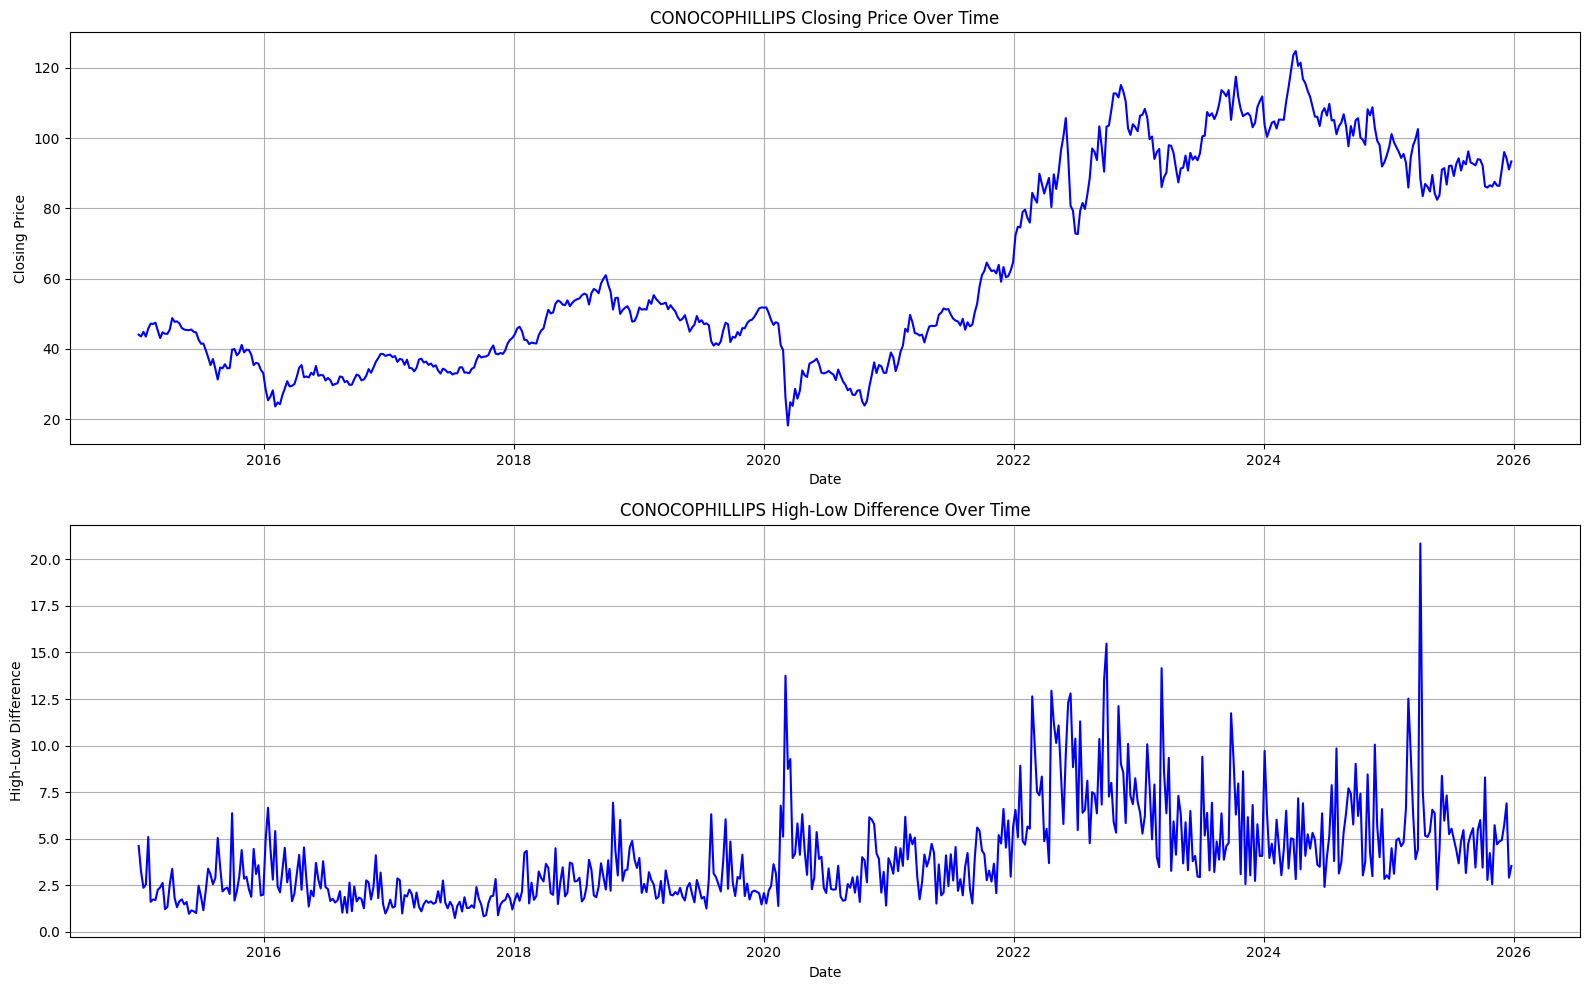

CONOCOPHILLIPS Log Returns Excess Kurtosis: 11.929298851880008
CONOCOPHILLIPS Open-Close Diff Excess Kurtosis: 2.567983129204544


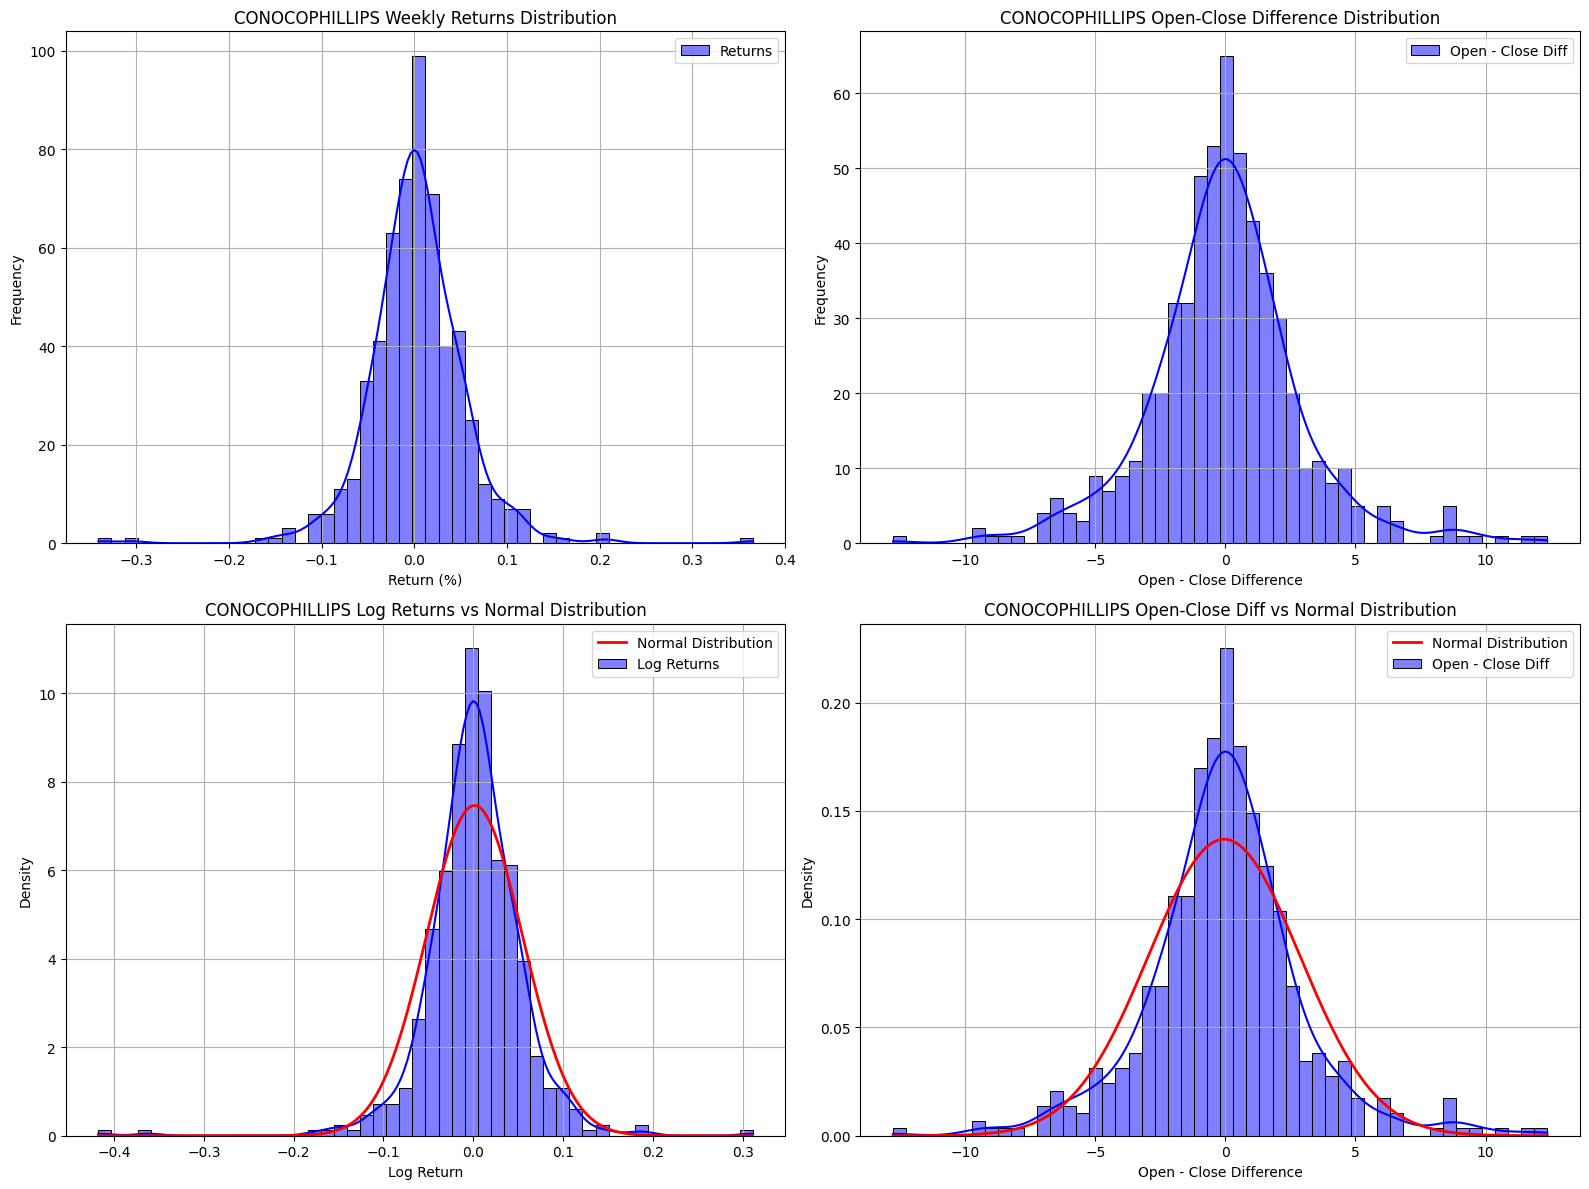

In [67]:
plot_financial_analysis(df, ticker="ConocoPhillips", color="blue")

## **Part 1.4**: Splitting and Exporting Data

In [68]:
# Ensure the index is a datetime object.
df.index = pd.to_datetime(df.index)

df.head()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return
Date,,,,,,,,,,
2015-01-01,44.045,48.307,43.697,47.625,47045900,NaN,NaN,4.610,3.581,NaN
2015-01-08,43.537,45.533,42.307,45.088,46895800,-0.012,0.012,3.226,1.550,-0.011601
2015-01-15,44.872,45.039,42.675,44.225,34895600,0.031,0.031,2.364,-0.647,0.030203
2015-01-22,43.509,45.991,43.454,45.261,35632700,-0.030,0.030,2.538,1.752,-0.030846
2015-01-29,45.797,47.250,42.161,43.926,59835200,0.053,0.053,5.089,-1.870,0.051251


In [69]:
#Spliting data into
#Train 80% (~459 weeks (8 years))
#Test: 10%  (~115 weeks (2 years))
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

print(f"Shape of train_features: {train.shape}")
print(f"Shape of test_features: {test.shape}")

Shape of train_features: (459, 10)
Shape of test_features: (115, 10)


In [70]:
# Comment / Uncomment on final

File_name = "COP_Forecasting.csv"

# Save to CSV
df.to_csv(File_name)

files.download(File_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Section 2**:  ARIMA and SARIMA Models

## **Part 2.1**:  Checking for Stationary and Autocorrelation

In [71]:
# Implementing the adfuller test to for Stationary
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.6059497657976878
p-value: 0.869631948032626


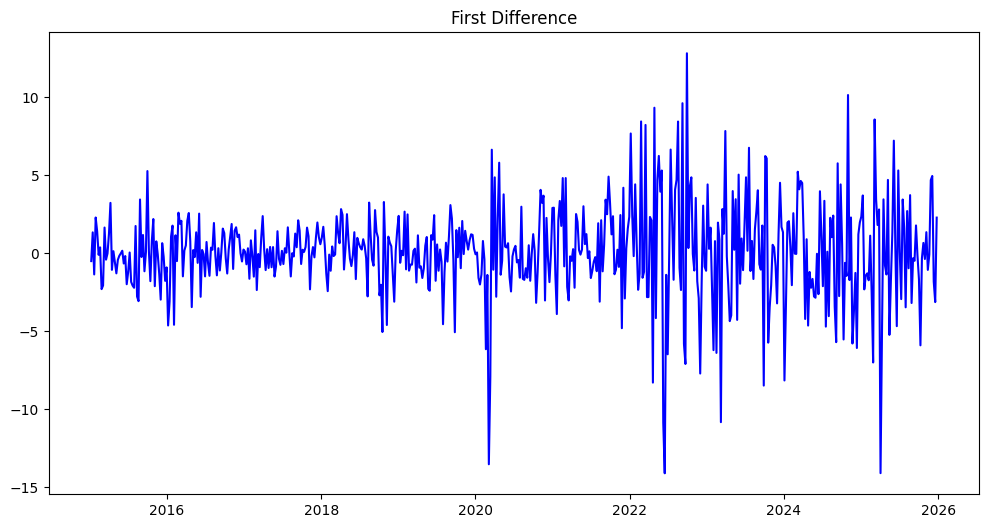

In [72]:
# Single Difference to achieve Stationarity
diff_series = df['Close'].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(diff_series, color='blue')
plt.title("First Difference")
plt.show()

In [73]:
#Test again for Stationary
result_diff = adfuller(diff_series.dropna())

print("ADF Statistic (diff):", result_diff[0])
print("p-value (diff):", result_diff[1])

ADF Statistic (diff): -6.870283884637155
p-value (diff): 1.521832510240226e-09


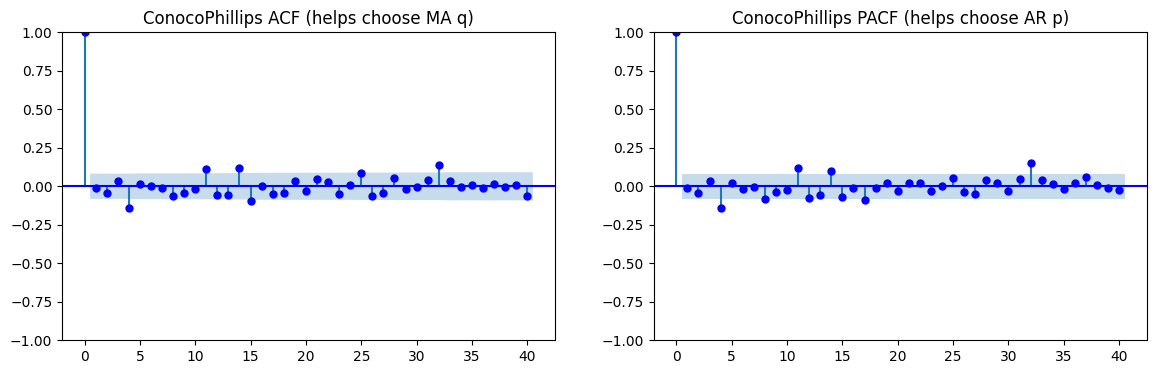

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF (MA terms)
plot_acf(diff_series, lags=40, ax=axes[0])
axes[0].set_title("ConocoPhillips ACF (helps choose MA q)")

for line in axes[0].lines:
    line.set_color('blue')

# PACF (AR terms)
plot_pacf(diff_series, lags=40, ax=axes[1])
axes[1].set_title("ConocoPhillips PACF (helps choose AR p)")

for line in axes[1].lines:
    line.set_color('blue')

plt.show()

## **Part 2.2**:  Fitting ARIMA and SARIMA Models

In [75]:
auto_model_search = pm.auto_arima(
    train['Close'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,            # let auto_arima determine the differencing
    seasonal=False,     # Enable seasonality
    m=52,              # Set seasonal period to 52 for weekly data
    stepwise=True,     # faster stepwise search
    trace=True         # shows progress
)

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:62: UserWarning:

m (52) set for non-seasonal fit. Setting to 0



Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2260.826, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2262.823, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2262.823, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2260.281, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2264.823, Time=0.54 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.358 seconds


In [76]:
# Best parameters from the search
p, d, q = 0, 1, 0

auto_model = sm.tsa.statespace.SARIMAX(
    train['Close'],
    order=(p, d, q),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  459
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1127.159
Date:                Thu, 30 Apr 2026   AIC                           2256.318
Time:                        01:35:57   BIC                           2260.442
Sample:                    01-01-2015   HQIC                          2257.942
                         - 10-12-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         8.1253      0.299     27.191      0.000       7.540       8.711
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               409.61
Prob(Q):                              0.96   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.



In [77]:
# Comment / Uncomment on final

#Searching through parameters
p_vals = [1, 2, 3]
q_vals = [0, 1]
P_vals = [0, 1]
Q_vals = [0, 1]

d, D, m = 1, 1, 52   # FIXED

results = []

for p, q in itertools.product(p_vals, q_vals):
    for P, Q in itertools.product(P_vals, Q_vals):
        try:
            model = sm.tsa.statespace.SARIMAX(
                train['Close'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, m),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False, maxiter=50)

            results.append(((p,d,q,P,D,Q), model.aic))
            print((p,d,q,P,D,Q), "AIC:", model.aic)

        except Exception:
            continue

results.sort(key=lambda x: x[1])

print("\nTop 5 models:")
for r in results[:5]:
    print(r)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.



(1, 1, 0, 0, 1, 0) AIC: 2280.4401190130893


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.



(1, 1, 0, 0, 1, 1) AIC: 1855.229135175704


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.



...

(3, 1, 1, 0, 1, 1) AIC: 1851.2149398182194


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.



(3, 1, 1, 1, 1, 0) AIC: 1889.427593171798


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.



(3, 1, 1, 1, 1, 1) AIC: 1853.926417599331

Top 5 models:
((1, 1, 1, 0, 1, 1), np.float64(1849.659666660155))
((2, 1, 1, 0, 1, 1), np.float64(1850.8173969300972))
((3, 1, 1, 0, 1, 1), np.float64(1851.2149398182194))
((3, 1, 1, 1, 1, 1), np.float64(1853.926417599331))
((1, 1, 0, 0, 1, 1), np.float64(1855.229135175704))


In [78]:
# Best parameters from the search
p, d, q = 1, 1, 1
P, D, Q, m = 0, 1, 1, 52

seasonal_auto_model = sm.tsa.statespace.SARIMAX(
    train['Close'],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(seasonal_auto_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-THU will be used.



                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                  459
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)   Log Likelihood                -920.830
Date:                            Thu, 30 Apr 2026   AIC                           1849.660
Time:                                    01:46:13   BIC                           1865.114
Sample:                                01-01-2015   HQIC                          1855.810
                                     - 10-12-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7921      0.119     -6.675      0.000      -1.025      -0.560
ma.L1          1.1730      0.149   

In [79]:
#Getting predictions from ARIMA and SARIMA models
forecast = auto_model.get_forecast(steps=len(test)).predicted_mean
seasonal_forecast = seasonal_auto_model.get_forecast(steps=len(test)).predicted_mean

In [80]:
#ARIMA metrics
mse__ARIMA = (mean_squared_error(test['Close'], forecast))
mae__ARIMA = mean_absolute_error(test['Close'], forecast)
rmse_ARIMA = np.sqrt(mean_squared_error(test['Close'], forecast))
mape_ARIMA = np.mean(np.abs((test['Close'] - forecast) / test['Close'])) * 100

print(f"MSE:  {mse__ARIMA:.4f}")
print(f"MAE:  {mae__ARIMA:.4f}")
print(f"RMSE: {rmse_ARIMA:.4f}")
print(f"MAPE: {mape_ARIMA:.4f}%")

MSE:  406.9780
MAE:  18.1659
RMSE: 20.1737
MAPE: 19.2106%


In [81]:
#SARIMA metrics
mse_SARIMA = (mean_squared_error(test['Close'], seasonal_forecast))
mae_SARIMA = mean_absolute_error(test['Close'], seasonal_forecast)
rmse_SARIMA = np.sqrt(mean_squared_error(test['Close'], seasonal_forecast))
mape_SARIMA = np.mean(np.abs((test['Close'] - seasonal_forecast) / test['Close'])) * 100

print(f"MSE:  {mse_SARIMA:.4f}")
print(f"MAE:  {mae_SARIMA:.4f}")
print(f"RMSE: {rmse_SARIMA:.4f}")
print(f"MAPE: {mape_SARIMA:.4f}%")

MSE:  949.0861
MAE:  27.1124
RMSE: 30.8072
MAPE: 28.7799%


## **Part 2.3**:  Checking ARIMA and SARIMA Assumptions

ARIMA Assumptions
CONOCOPHILLIPS Residual Mean: 0.2560174291938998


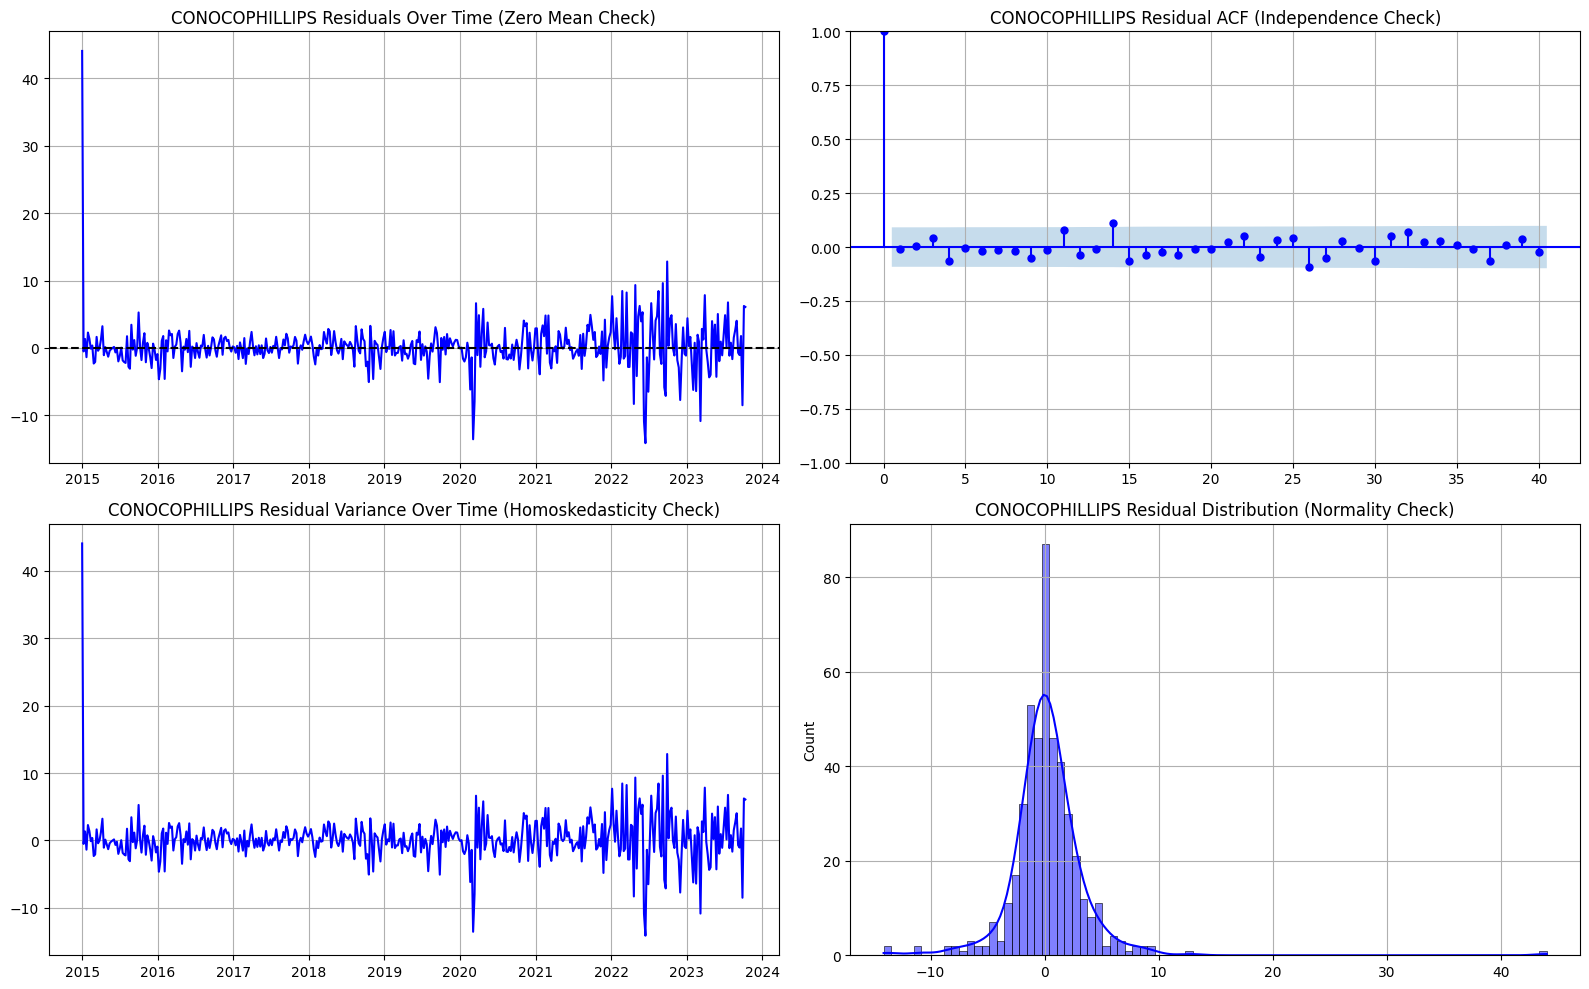

In [82]:
print("ARIMA Assumptions")
plot_residual_diagnostics(fit=auto_model, ticker="ConocoPhillips", color="blue")

SARIMA Assumptions
CONOCOPHILLIPS Residual Mean: 0.1649178089833149


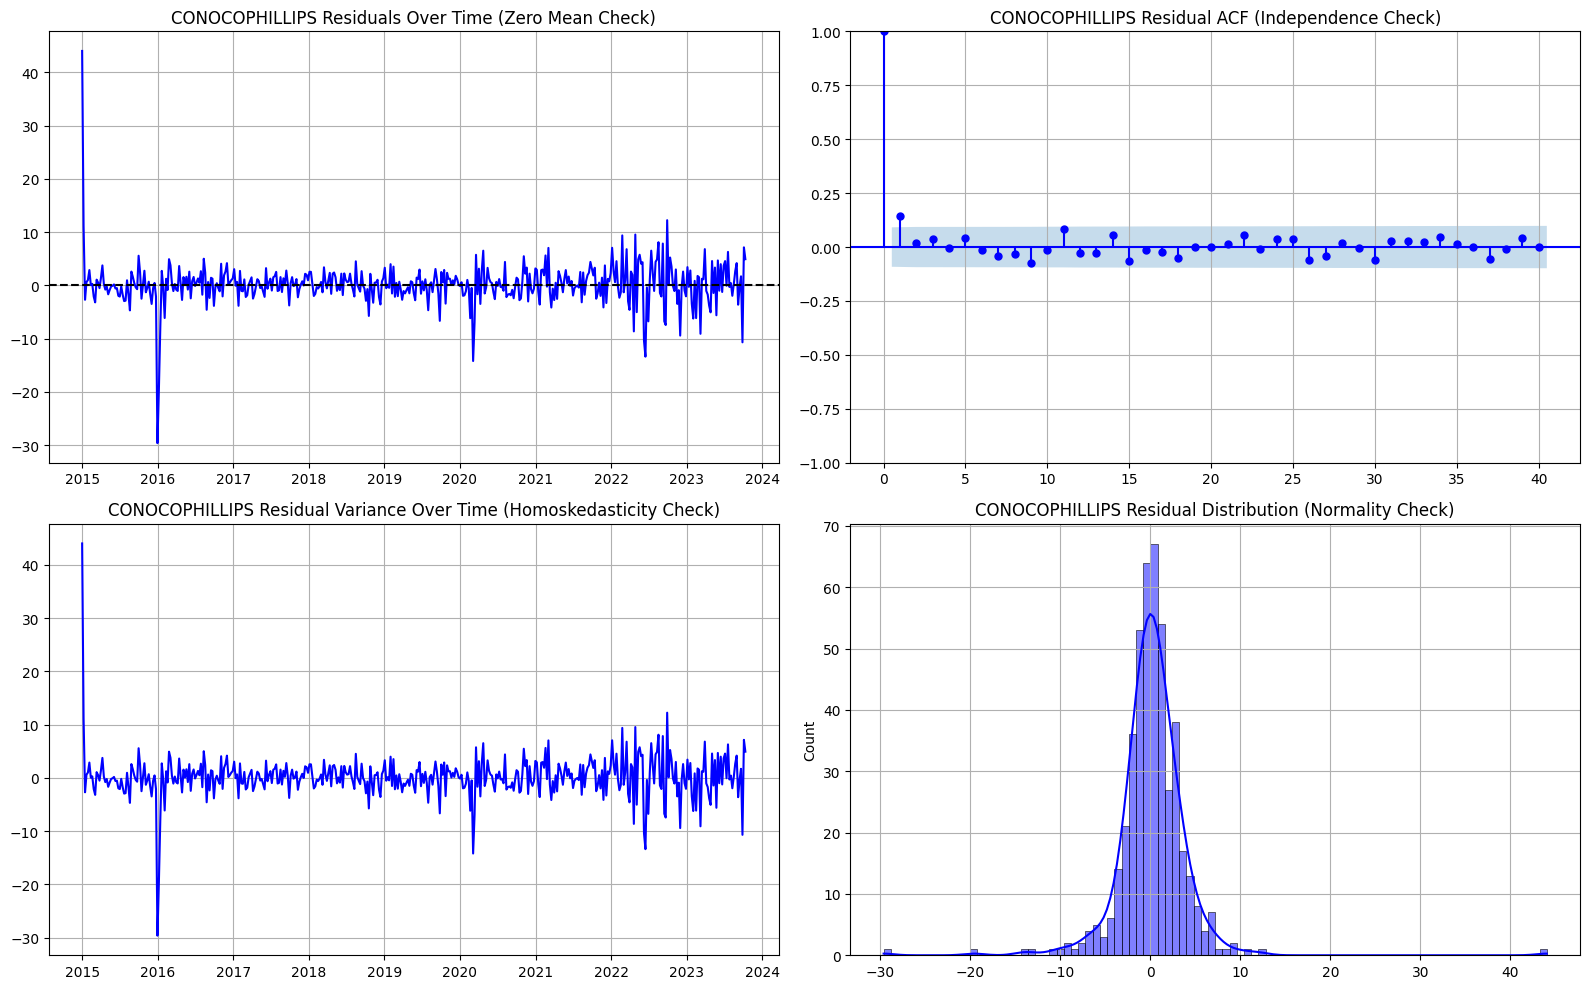

In [83]:
print("SARIMA Assumptions")
plot_residual_diagnostics(fit=seasonal_auto_model, ticker="ConocoPhillips", color="blue")

## **Part 2.4**:  ARIMA and SARIMA Forecast Visualized

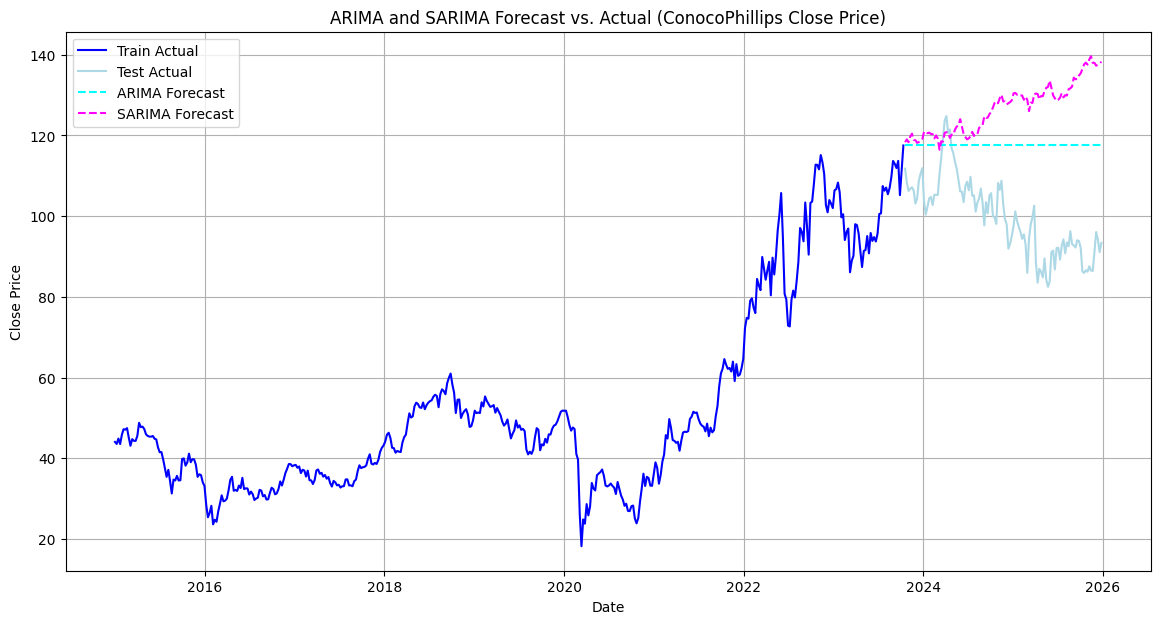

In [84]:
plt.figure(figsize=(14, 7))
plt.plot(train['Close'], label='Train Actual', color='blue')
plt.plot(test['Close'], label='Test Actual', color='lightblue')
plt.plot(forecast, label='ARIMA Forecast', color='cyan', linestyle='--')
plt.plot(seasonal_forecast, label='SARIMA Forecast', color='magenta', linestyle='--')

plt.title('ARIMA and SARIMA Forecast vs. Actual (ConocoPhillips Close Price)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# **Section 3**: XGBoost Model  

In [85]:
df

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return
Date,,,,,,,,,,
2015-01-01,44.045,48.307,43.697,47.625,47045900,NaN,NaN,4.610,3.581,NaN
2015-01-08,43.537,45.533,42.307,45.088,46895800,-0.012,0.012,3.226,1.550,-0.011601
2015-01-15,44.872,45.039,42.675,44.225,34895600,0.031,0.031,2.364,-0.647,0.030203
2015-01-22,43.509,45.991,43.454,45.261,35632700,-0.030,0.030,2.538,1.752,-0.030846
2015-01-29,45.797,47.250,42.161,43.926,59835200,0.053,0.053,5.089,-1.870,0.051251
...,...,...,...,...,...,...,...,...,...,...
2025-11-27,91.101,91.131,86.209,86.417,22612700,0.054,0.054,4.922,-4.684,0.052784
2025-12-04,96.053,96.658,90.932,90.932,41978200,0.054,0.054,5.725,-5.120,0.052931
2025-12-11,94.227,96.955,90.059,95.417,41620300,-0.019,0.019,6.896,1.191,-0.019193


## **Part 3.1**:  Feature Engineering for Machine Learning


In [86]:
# Copy df for feature engineering
df_features = df.copy()

# Reset the index to make 'Date' a regular column
df_features = df_features.reset_index()

# Extract time-based features
df_features['year'] = df_features['Date'].dt.year
df_features['month'] = df_features['Date'].dt.month
df_features['day'] = df_features['Date'].dt.day
df_features['dayofweek'] = df_features['Date'].dt.dayofweek
df_features['dayofyear'] = df_features['Date'].dt.dayofyear
df_features['weekofyear'] = df_features['Date'].dt.isocalendar().week.astype(int)

# Drop the original 'Date' column as it's no longer needed in its original form
df_features = df_features.drop(columns=['Date'])

# Display basic info
df_features.head()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return,year,month,day,dayofweek,dayofyear,weekofyear
0,44.045,48.307,43.697,47.625,47045900,NaN,NaN,4.610,3.581,NaN,2015,1,1,3,1,1
1,43.537,45.533,42.307,45.088,46895800,-0.012,0.012,3.226,1.550,-0.011601,2015,1,8,3,8,2
2,44.872,45.039,42.675,44.225,34895600,0.031,0.031,2.364,-0.647,0.030203,2015,1,15,3,15,3
3,43.509,45.991,43.454,45.261,35632700,-0.030,0.030,2.538,1.752,-0.030846,2015,1,22,3,22,4
4,45.797,47.250,42.161,43.926,59835200,0.053,0.053,5.089,-1.870,0.051251,2015,1,29,3,29,5


In [87]:
# Assume the target column is named 'Close' (change if needed)
target_col = 'Close'

# Create lag features
def create_lags(data, col, lags=5):
    df_features = data.copy()
    for i in range(1, lags+1):
        df_features[f'lag_{i}'] = df_features[col].shift(i)
    return df_features

df_features = create_lags(df_features, target_col, lags=10)

# Drop NA values from lagging
df_features = df_features.dropna()

df_features.head()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return,...,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
10,44.727,45.198,42.570,43.279,36119900,0.038,0.038,2.629,-1.448,0.037449,...,43.083,45.156,47.461,47.090,47.194,45.797,43.509,44.872,43.537,44.045
11,44.313,45.107,43.891,44.123,39435300,-0.009,0.009,1.216,-0.190,-0.009299,...,44.727,43.083,45.156,47.461,47.090,47.194,45.797,43.509,44.872,43.537
12,44.292,45.086,43.743,44.945,36225400,-0.000,0.000,1.342,0.654,-0.000474,...,44.313,44.727,43.083,45.156,47.461,47.090,47.194,45.797,43.509,44.872
13,45.550,46.548,43.975,44.074,31827000,0.028,0.028,2.572,-1.476,0.028007,...,44.292,44.313,44.727,43.083,45.156,47.461,47.090,47.194,45.797,43.509
14,48.776,48.958,45.585,45.697,39428400,0.071,0.071,3.374,-3.078,0.068428,...,45.550,44.292,44.313,44.727,43.083,45.156,47.461,47.090,47.194,45.797


In [88]:
#Spliting our feature engineered data into
#Train 80% (~451 weeks (8 years))
#Test: 10%  (~113 weeks (2 years))
train_size = int(len(df_features) * 0.8)

train_features = df_features.iloc[:train_size]
test_features = df_features.iloc[train_size:]

X_train = train_features.drop(columns=[target_col])
y_train = train_features[target_col]

X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]


print(f"Shape of train_features: {train_features.shape}")
print(f"Shape of test_features: {test_features.shape}")

Shape of train_features: (451, 26)
Shape of test_features: (113, 26)


## **Part 3.2**: Fitting XGBoost Model


In [89]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=50),
    params,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3
)

search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_squared_error')

In [90]:
results = pd.DataFrame(search.cv_results_)
results.sort_values("rank_test_score")[[
    "params",
    "mean_test_score",
    "rank_test_score"
]]

best_model = search.best_estimator_
search.best_params_

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}

## **Part 3.3**: XGBoost Forecast Results

In [91]:
# Predictions
preds = best_model.predict(X_test)

#XGBoost Metrics
mse_XGBoost  = mean_squared_error(y_test, preds)
mae_XGBoost  = mean_absolute_error(y_test, preds)
rmse_XGBoost = np.sqrt(mean_squared_error(y_test, preds))
mape_XGBoost = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"MSE:  {mse_XGBoost:.4f}")
print(f"MAE:  {mae_XGBoost:.4f}")
print(f"RMSE: {rmse_XGBoost:.4f}")
print(f"MAPE: {mape_XGBoost:.4f}%")

MSE:  5.0116
MAE:  1.3999
RMSE: 2.2387
MAPE: 1.3512%


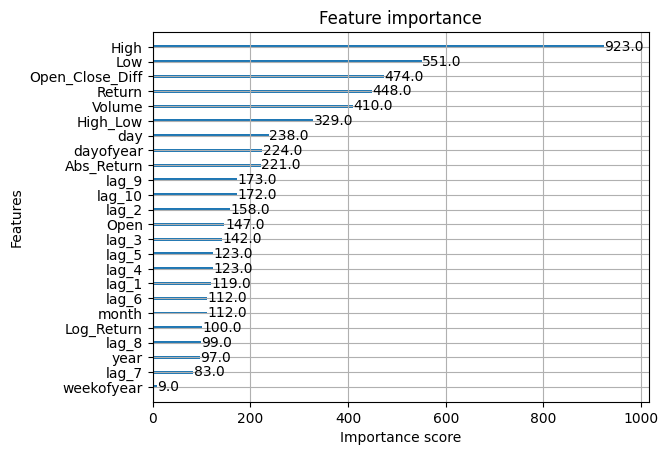

In [92]:
plot_importance(best_model)
plt.show()

## **Part 3.4**: XGBoost Visualized

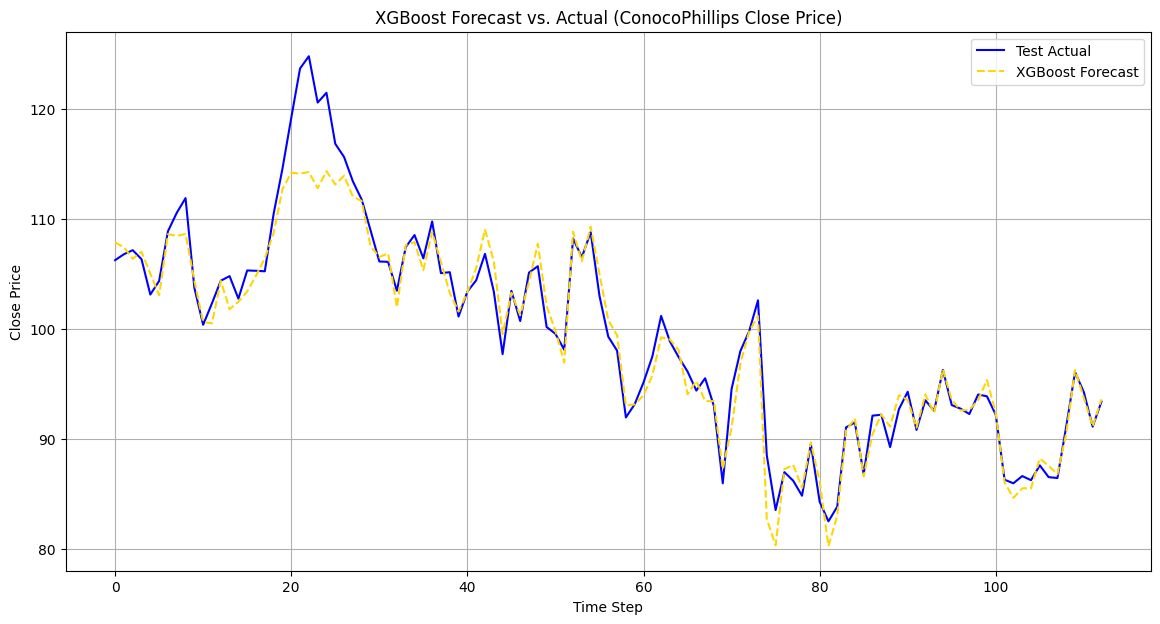

In [93]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Test Actual', color='blue')
plt.plot(preds, label='XGBoost Forecast', color='gold', linestyle='--')

plt.title('XGBoost Forecast vs. Actual (ConocoPhillips Close Price)')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# **Section 4**: LSTM Model  

In [94]:
df_stripped = df.replace([np.inf, -np.inf], np.nan)
df_stripped = df_stripped.dropna()

## **Part 4.1**:  Feature Engineering and Scaling for Neural Networks

In [95]:
features = ['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'High_Low', 'Open_Close_Diff', 'Abs_Return']

data = df_stripped[features]

data.head()

Price,Close,High,Low,Open,Volume,Return,High_Low,Open_Close_Diff,Abs_Return
Date,,,,,,,,,
2015-01-08,43.537,45.533,42.307,45.088,46895800,-0.012,3.226,1.550,0.012
2015-01-15,44.872,45.039,42.675,44.225,34895600,0.031,2.364,-0.647,0.031
2015-01-22,43.509,45.991,43.454,45.261,35632700,-0.030,2.538,1.752,0.030
2015-01-29,45.797,47.250,42.161,43.926,59835200,0.053,5.089,-1.870,0.053
2015-02-05,47.194,47.702,46.089,46.596,40673600,0.031,1.613,-0.598,0.031


In [96]:
#scaling data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [97]:
#Sliding Window
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)
X, y = create_sequences(scaled_data, 60)
X.shape, y.shape

((513, 60, 9), (513,))

In [98]:
split = int(0.8 * len(X))
X_stripped_train = X[:split]
X_stripped_test = X[split:]
y_stripped_train = y[:split]
y_stripped_test = y[split:]

print("X shape:", X.shape)


X shape: (513, 60, 9)


## **Part 4.2**: Fitting LSTM Model

In [99]:
def build_model():
    model = Sequential()

    model.add(LSTM(
        64,
        return_sequences=True,
        input_shape=(X.shape[1], X.shape[2])
    ))

    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(32))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

In [100]:
model = build_model()

history = model.fit(
    X_stripped_train, y_stripped_train,
    epochs=60,
    batch_size=64,
    validation_data=(X_stripped_test, y_stripped_test)
)

# Training loss (final epoch value)
train_loss = history.history['loss'][-1]

# Validation loss (final epoch value)
val_loss = history.history['val_loss'][-1]

print(train_loss)
print(val_loss)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - loss: 0.0694 - val_loss: 0.0075
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0131 - val_loss: 0.0069
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0090 - val_loss: 0.0121
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0073 - val_loss: 0.0064
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0052 - val_loss: 0.0066
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0061 - val_loss: 0.0046
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0051 - val_loss: 0.0049
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 9/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0061 - val_loss: 0.0033
Epoch 10/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0046 - val_loss: 0.0037
Epoch 11/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0043 - val_loss: 0.0057
Epoch 12/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 0.0046 - val_loss: 0.0034

## **Part 4.3**: LSTM Forecast Results

In [101]:
predictions = model.predict(X_stripped_test)

#Convert Predictions Back to Original Scale
# create empty array to match original feature size
predicted_full = np.zeros((len(predictions), data.shape[1]))
predicted_full[:, 0] = predictions[:, 0]  # assuming 'Close' is index 0

predicted_prices = scaler.inverse_transform(predicted_full)[:, 0]

# actual values
actual_full = np.zeros((len(y_stripped_test), data.shape[1]))
actual_full[:, 0] = y_stripped_test

actual_prices = scaler.inverse_transform(actual_full)[:, 0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step


In [102]:
mse_lstm = mean_squared_error(actual_prices, predicted_prices)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(actual_prices, predicted_prices)
mape_lstm = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

print(mse_lstm)
print(rmse_lstm)
print(mae_lstm)
print(mape_lstm)

20.967638611205114
4.5790434166106255
3.6671323298204284
3.8160242829230304


## **Part 4.4**: LSTM Visualized

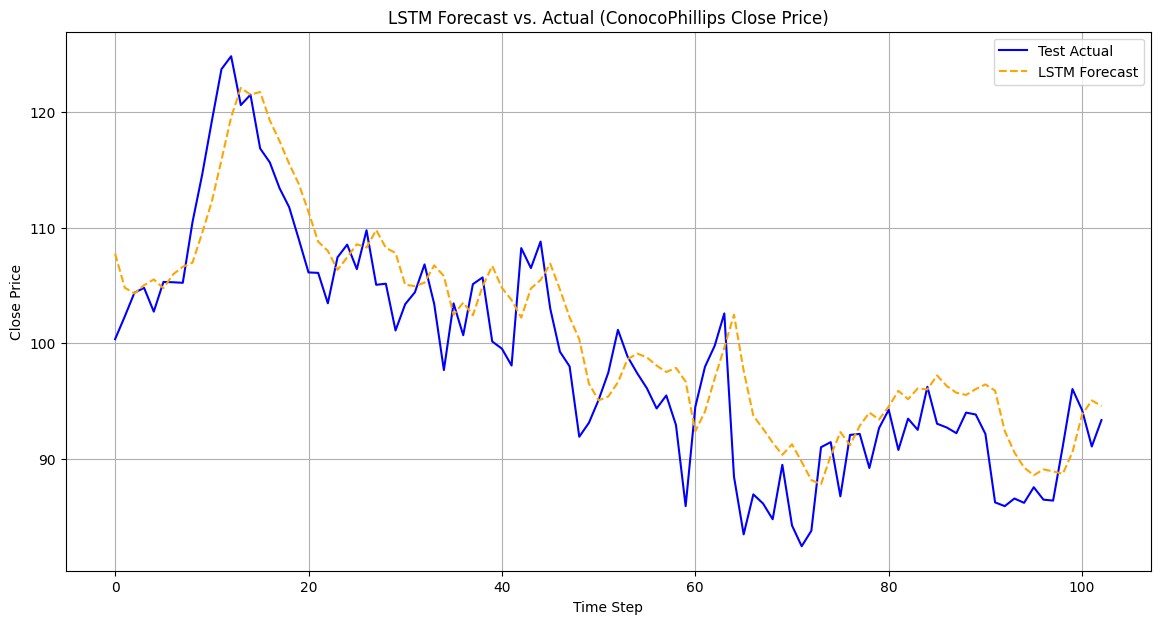

In [103]:
plt.figure(figsize=(14, 7))
plt.plot(actual_prices, label='Test Actual', color='blue')
plt.plot(predicted_prices, label='LSTM Forecast', color='orange', linestyle='--')

plt.title('LSTM Forecast vs. Actual (ConocoPhillips Close Price)')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# **Section 5**: Comparing Results    

## **Part 5.1**: Table comparing all model metrics

In [104]:
# Create a dictionary to hold the metrics for each model
metrics_data = {
    'Model': ['ARIMA', 'SARIMA', 'XGBoost', 'LSTM'],
    'MSE': [mse__ARIMA, mse_SARIMA, mse_XGBoost, mse_lstm],
    'MAE': [mae__ARIMA, mae_SARIMA, mae_XGBoost, mae_lstm],
    'RMSE': [rmse_ARIMA, rmse_SARIMA, rmse_XGBoost, rmse_lstm],
    'MAPE (%)': [mape_ARIMA, mape_SARIMA, mape_XGBoost, mape_lstm]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

# Display the DataFrame
display(metrics_df.round(4))

,Model,MSE,MAE,RMSE,MAPE (%)
0,ARIMA,406.9780,18.1659,20.1737,19.2106
1,SARIMA,949.0861,27.1124,30.8072,28.7799
2,XGBoost,5.0116,1.3999,2.2387,1.3512
3,LSTM,20.9676,3.6671,4.5790,3.8160


## **Part 5.2**: Visual plot of all forecasts

In [105]:
forecasts = {
    "ARIMA Forecast": (forecast, 'cyan'),
    "SARIMA Forecast": (seasonal_forecast, 'magenta'),
    "XGBoost Forecast": (preds, 'gold'),
    "LSTM Forecast": (predicted_prices, 'orange')
}

common_test_actual = test['Close']

In [106]:
fig = plot_forecast(
    df,
    train,
    common_test_actual,
    forecasts,
    ticker='ConocoPhillips',
    template='presentation',
    test_color='lightblue',
    actual_color='blue'
)

fig.show()